In [71]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

In [72]:
df = pd.read_csv('../data/processed/bank-marketing-clean.csv')
df.head()

,age,job,marital-status,education,default-credit,yearly-balance,housing-loan,personal-loan,last-contact-type,last-contact-day,last-contact-month,last-contact-duration-seconds,current-campaign-contacts,passed-days,previous-campaigns,outcome-previous-campaign,suscribed-term-deposited
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   age                            4521 non-null   int64 
 1   job                            4521 non-null   object
 2   marital-status                 4521 non-null   object
 3   education                      4521 non-null   object
 4   default-credit                 4521 non-null   object
 5   yearly-balance                 4521 non-null   int64 
 6   housing-loan                   4521 non-null   object
 7   personal-loan                  4521 non-null   object
 8   last-contact-type              4521 non-null   object
 9   last-contact-day               4521 non-null   int64 
 10  last-contact-month             4521 non-null   object
 11  last-contact-duration-seconds  4521 non-null   int64 
 12  current-campaign-contacts      4521 non-null   int64 
 13  pas

Convert binary columns

In [74]:
binary = [
    'default-credit',
    'housing-loan',
    'personal-loan',
    'suscribed-term-deposited'
]

for col in binary:
    df[col] = df[col].map({'no': 0, 'yes': 1})

In [75]:
df.head()

,age,job,marital-status,education,default-credit,yearly-balance,housing-loan,personal-loan,last-contact-type,last-contact-day,last-contact-month,last-contact-duration-seconds,current-campaign-contacts,passed-days,previous-campaigns,outcome-previous-campaign,suscribed-term-deposited
0,30,unemployed,married,primary,0,1787,0,0,cellular,19,oct,79,1,-1,0,unknown,0
1,33,services,married,secondary,0,4789,1,1,cellular,11,may,220,1,339,4,failure,0
2,35,management,single,tertiary,0,1350,1,0,cellular,16,apr,185,1,330,1,failure,0
3,30,management,married,tertiary,0,1476,1,1,unknown,3,jun,199,4,-1,0,unknown,0
4,59,blue-collar,married,secondary,0,0,1,0,unknown,5,may,226,1,-1,0,unknown,0


Convert Categorical variables

In [76]:
df = pd.get_dummies(
    df,
    columns = [
        'job',
        'marital-status',
        'education',
        'last-contact-type',
        'last-contact-month',
        'outcome-previous-campaign'
    ],
    drop_first = True
)
df.head()

,age,default-credit,yearly-balance,housing-loan,personal-loan,last-contact-day,last-contact-duration-seconds,current-campaign-contacts,passed-days,previous-campaigns,...,last-contact-month_jul,last-contact-month_jun,last-contact-month_mar,last-contact-month_may,last-contact-month_nov,last-contact-month_oct,last-contact-month_sep,outcome-previous-campaign_other,outcome-previous-campaign_success,outcome-previous-campaign_unknown
0,30,0,1787,0,0,19,79,1,-1,0,...,False,False,False,False,False,True,False,False,False,True
1,33,0,4789,1,1,11,220,1,339,4,...,False,False,False,True,False,False,False,False,False,False
2,35,0,1350,1,0,16,185,1,330,1,...,False,False,False,False,False,False,False,False,False,False
3,30,0,1476,1,1,3,199,4,-1,0,...,False,True,False,False,False,False,False,False,False,True
4,59,0,0,1,0,5,226,1,-1,0,...,False,False,False,True,False,False,False,False,False,True


In [77]:
df.shape

(4521, 43)

In [78]:
X = df.drop(columns = ['suscribed-term-deposited'])
y = df['suscribed-term-deposited']

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [80]:
cl = DecisionTreeClassifier(
    max_depth = 4,
    random_state=42,
)
cl.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [81]:
print(export_text(
    cl,
    feature_names=X.columns.tolist(),
    show_weights=True
))

|--- last-contact-duration-seconds <= 645.50
|   |--- outcome-previous-campaign_success <= 0.50
|   |   |--- last-contact-duration-seconds <= 222.50
|   |   |   |--- last-contact-month_oct <= 0.50
|   |   |   |   |--- weights: [2029.00, 45.00] class: 0
|   |   |   |--- last-contact-month_oct >  0.50
|   |   |   |   |--- weights: [19.00, 9.00] class: 0
|   |   |--- last-contact-duration-seconds >  222.50
|   |   |   |--- last-contact-month_oct <= 0.50
|   |   |   |   |--- weights: [978.00, 141.00] class: 0
|   |   |   |--- last-contact-month_oct >  0.50
|   |   |   |   |--- weights: [9.00, 15.00] class: 1
|   |--- outcome-previous-campaign_success >  0.50
|   |   |--- last-contact-duration-seconds <= 182.50
|   |   |   |--- age <= 44.50
|   |   |   |   |--- weights: [5.00, 6.00] class: 1
|   |   |   |--- age >  44.50
|   |   |   |   |--- weights: [10.00, 0.00] class: 0
|   |   |--- last-contact-duration-seconds >  182.50
|   |   |   |--- yearly-balance <= 11133.50
|   |   |   |   |--- w

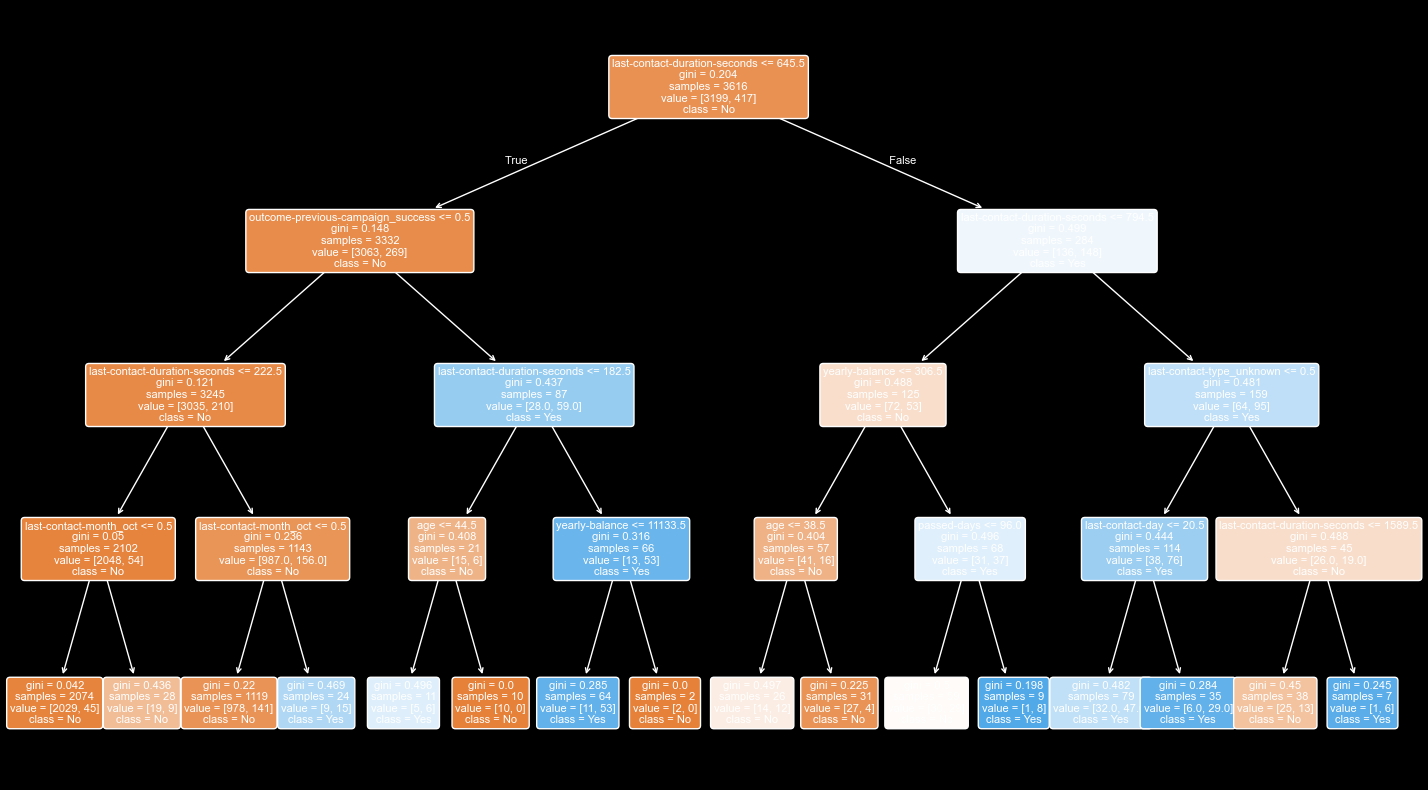

In [82]:
plt.figure(figsize=(18,10))

plot_tree(
    cl,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [83]:
pred_train = cl.predict(X_train)
pred_test = cl.predict(X_test)

In [84]:
print(accuracy_score(y_train, pred_train))
print(accuracy_score(y_test, pred_test))

0.9120575221238938
0.8861878453038674


In [85]:
confusion_matrix(y_test, pred_test)

array([[771,  30],
       [ 73,  31]])

In [86]:
print(classification_report(
    y_test,
    pred_test,
    target_names=['No', 'Yes']
))

              precision    recall  f1-score   support

          No       0.91      0.96      0.94       801
         Yes       0.51      0.30      0.38       104

    accuracy                           0.89       905
   macro avg       0.71      0.63      0.66       905
weighted avg       0.87      0.89      0.87       905



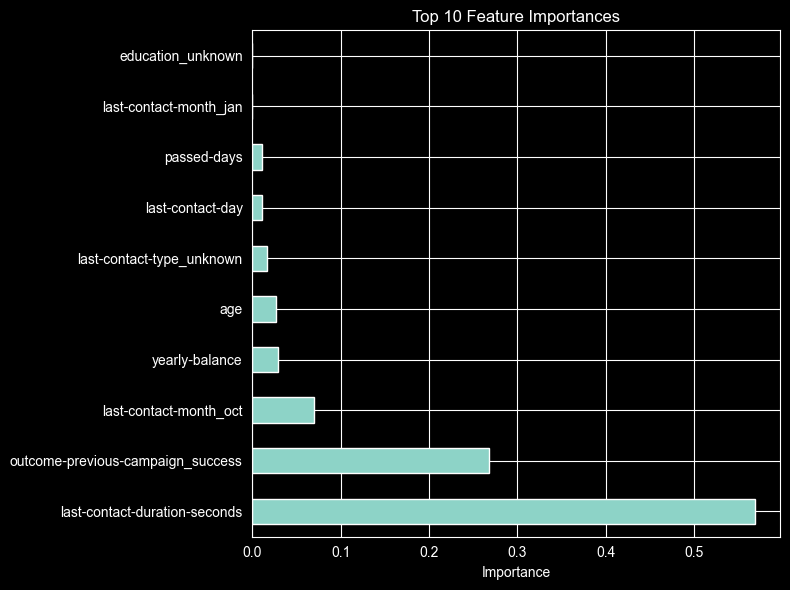

In [87]:
importance = pd.Series(
    cl.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importance.head(10).plot(kind='barh')

plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()